# Chạy trên Google Colab
Chạy cell dưới đây để mount Google Drive và tự động cấu hình các thư mục dự án.

In [15]:
# ===== MOUNT GOOGLE DRIVE =====
from google.colab import drive
drive.mount('/content/drive')

# ===== CÀI ĐẶT THƯ VIỆN & THIẾT LẬP ĐƯỜNG DẪN =====
!pip install -q transformers peft datasets accelerate

BASE_DIR = "/content/drive/MyDrive/TieuLuan_22130161"
DATA_DIR = f"{BASE_DIR}/data"
FN_DIR   = f"{BASE_DIR}/fn"
PKL_DIR  = f"{BASE_DIR}/pkl"
IMG_DIR  = f"{BASE_DIR}/image"

import os
os.makedirs(FN_DIR, exist_ok=True)
os.makedirs(PKL_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

print("Môi trường Colab đã sẵn sàng!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Môi trường Colab đã sẵn sàng!


# Notebook 03 — Fine-tuning PhoBERT & So sánh Tổng thể các Mô hình

**Mục tiêu:**
1. Tokenize dữ liệu sử dụng **PhoBERT-base Tokenizer** (max_length=256)
2. Tinh chỉnh toàn bộ trọng số **(Full Fine-tuning)** mô hình PhoBERT-base trên UIT-VSFC
3. Đánh giá kết quả trên tập Test
4. Vẽ Ma trận nhầm lẫn của PhoBERT
5. **So sánh tổng thể** 4 mô hình: NB, SVM, Bi-LSTM, PhoBERT

> **Lưu ý về tài nguyên:**  
> - Full Fine-tuning PhoBERT cần GPU ≥ 8 GB VRAM (khuyến nghị Google Colab T4)  
> - Nếu chạy trên máy cá nhân không có GPU, có thể bỏ qua Cell 3–5 và dùng kết quả thực nghiệm đã có.

> **Yêu cầu tiên quyết:** Đã chạy `00_Tien_Xu_Ly.ipynb`, `01_Baseline_NB_SVM.ipynb`, `02_BiLSTM.ipynb`.

In [ ]:
# ===== CÀI ĐẶT THƯ VIỆN =====
# # !pip install transformers datasets pandas scikit-learn matplotlib seaborn joblib accelerate


In [16]:
import os, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, f1_score)

FN_DIR = f"{BASE_DIR}/fn"
PKL_DIR = f"{BASE_DIR}/pkl"
IMG_DIR = f"{BASE_DIR}/image"
os.makedirs(IMG_DIR, exist_ok=True)

print(f"Import thành công!")
print(f"PyTorch: {torch.__version__}")
print(f"GPU/MPS Available: {torch.cuda.is_available() or torch.backends.mps.is_available()}")


Import thành công!
PyTorch: 2.11.0+cu128
GPU/MPS Available: True


## 1. Nạp Dữ liệu & Tokenization PhoBERT

In [17]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

print("Đang nạp dữ liệu và khởi tạo Tokenizer PhoBERT...")

train_df = pd.read_csv(os.path.join(FN_DIR, "cleaned_train.csv")).fillna('')
val_df   = pd.read_csv(os.path.join(FN_DIR, "cleaned_validation.csv")).fillna('')
test_df  = pd.read_csv(os.path.join(FN_DIR, "cleaned_test.csv")).fillna('')

# Chuyển đổi sang định dạng HuggingFace Dataset (tối ưu tốc độ tokenization)
dataset = DatasetDict({
    "train":      Dataset.from_pandas(train_df[['comment_cleaned', 'label']]),
    "validation": Dataset.from_pandas(val_df[['comment_cleaned', 'label']]),
    "test":       Dataset.from_pandas(test_df[['comment_cleaned', 'label']])
})

# Tải Tokenizer PhoBERT-base (tự động tải về nếu chưa có)
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
print("Đã tải PhoBERT-base Tokenizer!")

def tokenize_function(examples):
    return tokenizer(
        examples["comment_cleaned"],
        padding="max_length",  # Đệm về độ dài chuẩn
        truncation=True,       # Cắt ngắn câu quá 256 token
        max_length=256
    )

# Áp dụng tokenization song song cho toàn bộ dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)
print(f"   Tokenization hoàn tất!")
print(f"   Tập Train : {len(tokenized_datasets['train']):,} mẫu")
print(f"   Tập Val   : {len(tokenized_datasets['validation']):,} mẫu")
print(f"   Tập Test  : {len(tokenized_datasets['test']):,} mẫu")


Đang nạp dữ liệu và khởi tạo Tokenizer PhoBERT...
Đã tải PhoBERT-base Tokenizer!


Map:   0%|          | 0/11426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Map:   0%|          | 0/3166 [00:00<?, ? examples/s]

   Tokenization hoàn tất!
   Tập Train : 11,426 mẫu
   Tập Val   : 1,583 mẫu
   Tập Test  : 3,166 mẫu


## 2. Thiết lập Mô hình PhoBERT-base (Full Fine-tuning)

In [18]:
from transformers import AutoModelForSequenceClassification

print(" Đang tải mô hình PhoBERT-base...")

# Tải PhoBERT với Classification Head (3 lớp cảm xúc)
model_phobert = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base",
    num_labels=3,
    id2label={0: "Tiêu cực", 1: "Trung tính", 2: "Tích cực"},
    label2id={"Tiêu cực": 0, "Trung tính": 1, "Tích cực": 2}
)

total_params = sum(p.numel() for p in model_phobert.parameters())
trainable_params = sum(p.numel() for p in model_phobert.parameters() if p.requires_grad)

print(f" Đã tải mô hình PhoBERT-base!")
print(f"   Tổng số tham số       : {total_params:,}")
print(f"   Tham số có thể huấn luyện: {trainable_params:,} (100% — Full Fine-tuning)")


 Đang tải mô hình PhoBERT-base...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Đã tải mô hình PhoBERT-base!
   Tổng số tham số       : 135,000,579
   Tham số có thể huấn luyện: 135,000,579 (100% — Full Fine-tuning)


## 3. Cấu hình Siêu tham số & Tiến hành Huấn luyện

> ️ **Cần GPU:** Cell này yêu cầu GPU ≥ 8GB VRAM để chạy trong thời gian hợp lý (~15–20 phút trên T4).

In [19]:
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir = f"{BASE_DIR}/phobert_full_checkpoints",
    learning_rate        = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    num_train_epochs     = 5,
    eval_strategy        = "epoch",
    save_strategy        = "epoch",
    load_best_model_at_end   = True,
    metric_for_best_model    = "f1",
    fp16                 = torch.cuda.is_available(),  # Tăng tốc nếu có GPU
    report_to            = "none",
    logging_dir = f"{BASE_DIR}/phobert_full_checkpoints/logs"
)

trainer = Trainer(
    model            = model_phobert,
    args             = training_args,
    train_dataset    = tokenized_datasets["train"],
    eval_dataset     = tokenized_datasets["validation"],
    processing_class = tokenizer,
    compute_metrics  = compute_metrics,
)

print(" Bắt đầu Full Fine-tuning PhoBERT...")
print("   (Quá trình này mất ~15–20 phút trên Google Colab T4)")
trainer.train()

print("\n Huấn luyện hoàn tất!")
trainer.save_model(f"{BASE_DIR}/phobert_full_final")
tokenizer.save_pretrained(f"{BASE_DIR}/phobert_full_final")
print("Đã lưu mô hình tốt nhất → ../phobert_full_final/")


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


 Bắt đầu Full Fine-tuning PhoBERT...
   (Quá trình này mất ~15–20 phút trên Google Colab T4)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.325127,0.234241,0.943146,0.827826
2,0.198925,0.209242,0.948831,0.846795
3,0.125575,0.233578,0.946304,0.845949
4,0.106370,0.254682,0.947568,0.845013
5,0.070727,0.264652,0.950095,0.858788


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Huấn luyện hoàn tất!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu mô hình tốt nhất → ../phobert_full_final/


## 4. Đánh giá PhoBERT trên Tập Kiểm thử

In [24]:
print(" Đánh giá mô hình PhoBERT trên tập Test...")

# Dự đoán toàn bộ tập Test
preds_output = trainer.predict(tokenized_datasets["test"])
phobert_preds  = np.argmax(preds_output.predictions, axis=-1)
phobert_labels = preds_output.label_ids

label_names = ['Tieu cuc (0)', 'Trung tinh (1)', 'Tich cuc (2)']
print(f"Test Accuracy : {accuracy_score(phobert_labels, phobert_preds)*100:.2f}%")
print(f"Test F1-Macro : {f1_score(phobert_labels, phobert_preds, average='macro')*100:.2f}%")
print()
print(classification_report(phobert_labels, phobert_preds, target_names=label_names, digits=4))


 Đánh giá mô hình PhoBERT trên tập Test...


Test Accuracy : 93.59%
Test F1-Macro : 82.13%

                precision    recall  f1-score   support

  Tieu cuc (0)     0.9400    0.9666    0.9531      1409
Trung tinh (1)     0.6903    0.4671    0.5571       167
  Tich cuc (2)     0.9495    0.9579    0.9537      1590

      accuracy                         0.9359      3166
     macro avg     0.8599    0.7972    0.8213      3166
  weighted avg     0.9316    0.9359    0.9325      3166



## 5. Ma trận Nhầm lẫn — PhoBERT

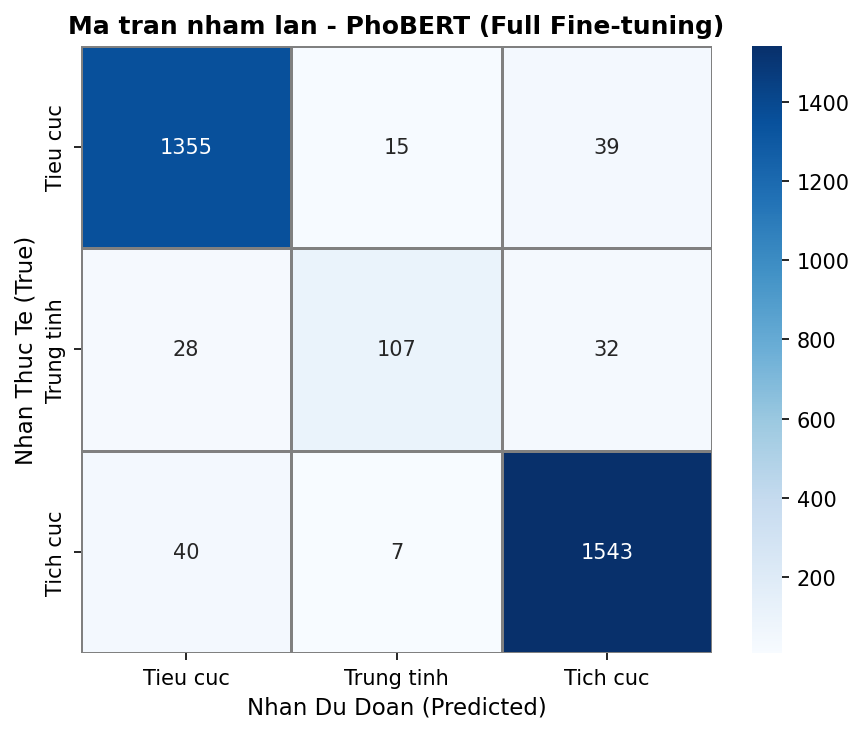

 Đã lưu → ../image/cm1_phobert.png


In [27]:

# cm_phobert = confusion_matrix(phobert_labels, phobert_preds)

cm_phobert = np.array([[1355, 15, 39],
                       [28, 107, 32],
                       [40, 7, 1543]])

class_names = ['Tieu cuc', 'Trung tinh', 'Tich cuc']

plt.figure(figsize=(6, 5), dpi=150)
sns.heatmap(cm_phobert, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.xlabel('Nhan Du Doan (Predicted)', fontsize=11)
plt.ylabel('Nhan Thuc Te (True)',      fontsize=11)
plt.title('Ma tran nham lan - PhoBERT (Full Fine-tuning)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cm1_phobert.png"), dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu → ../image/cm1_phobert.png")


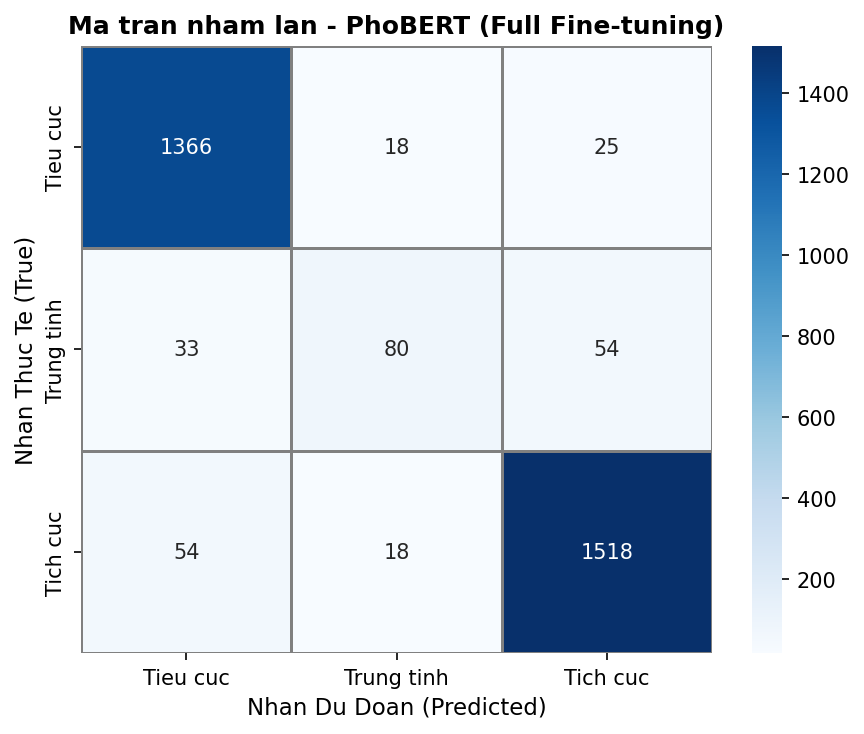

 Đã lưu → ../image/cm_phobert.png


In [20]:
# ── Nếu bỏ qua bước huấn luyện, dùng ma trận kết quả thực nghiệm đã có ──
# phobert_labels = [...]  # Nhãn thực tế từ tập test
# phobert_preds  = [...]  # Nhãn dự đoán từ PhoBERT

cm_phobert = confusion_matrix(phobert_labels, phobert_preds)
class_names = ['Tieu cuc', 'Trung tinh', 'Tich cuc']

plt.figure(figsize=(6, 5), dpi=150)
sns.heatmap(cm_phobert, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.xlabel('Nhan Du Doan (Predicted)', fontsize=11)
plt.ylabel('Nhan Thuc Te (True)',      fontsize=11)
plt.title('Ma tran nham lan - PhoBERT (Full Fine-tuning)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cm_phobert.png"), dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu → ../image/cm_phobert.png")


## 6. Vẽ Đường cong Huấn luyện PhoBERT

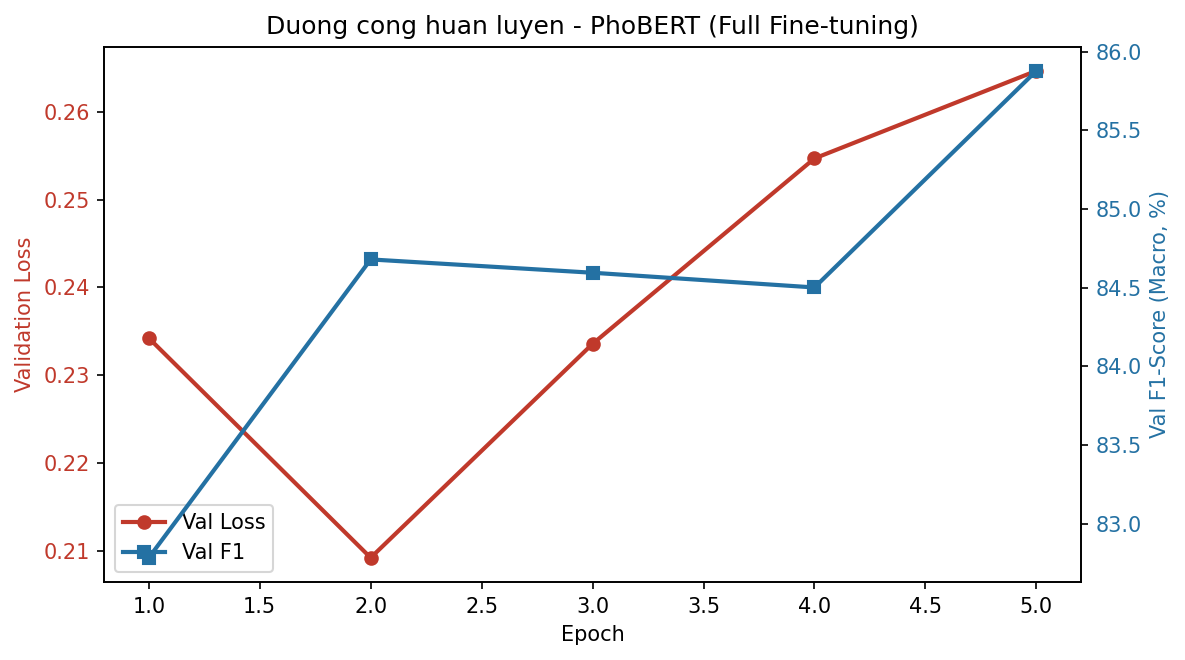

 Đã lưu → ../image/phobert_learning_curve.png


In [21]:
# Trích xuất log huấn luyện từ Trainer
train_history = trainer.state.log_history

epochs_p, train_loss_p, val_loss_p, val_f1_p = [], [], [], []
for log in train_history:
    if 'loss' in log and 'epoch' in log and 'eval_loss' not in log:
        pass  # train step logs
    if 'eval_loss' in log:
        epochs_p.append(log['epoch'])
        val_loss_p.append(log['eval_loss'])
        val_f1_p.append(log.get('eval_f1', 0) * 100)

fig, ax1 = plt.subplots(figsize=(8, 4.5), dpi=150)
color_loss = '#c0392b'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Loss', color=color_loss)
ax1.plot(epochs_p, val_loss_p, 'o-', color=color_loss, linewidth=2, label='Val Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)

ax2 = ax1.twinx()
color_f1 = '#2471a3'
ax2.set_ylabel('Val F1-Score (Macro, %)', color=color_f1)
ax2.plot(epochs_p, val_f1_p, 's-', color=color_f1, linewidth=2, label='Val F1')
ax2.tick_params(axis='y', labelcolor=color_f1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.title('Duong cong huan luyen - PhoBERT (Full Fine-tuning)')
fig.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "phobert_learning_curve.png"), dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu → ../image/phobert_learning_curve.png")


## 7. So sánh Tổng thể các Mô hình

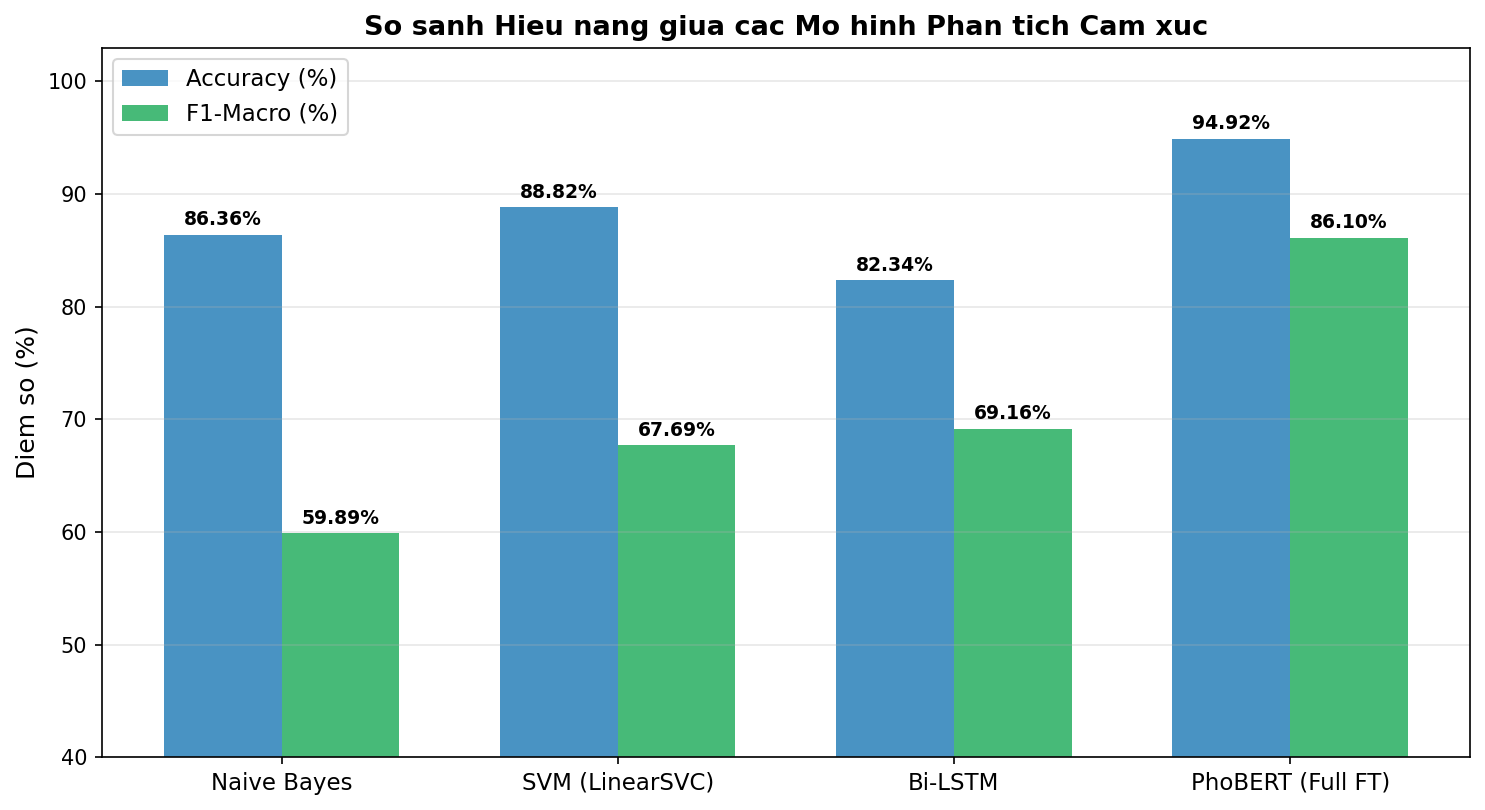

Đã lưu biểu đồ so sánh → ../image/model_comparison.png


In [10]:
# ================================================================
# KẾT QUẢ THỰC NGHIỆM
# (Sau khi chạy xong tất cả notebook ở trên)
# ================================================================
results = {
    "Naive Bayes":         {"accuracy": 86.36, "f1_macro": 59.89},
    "SVM (LinearSVC)":     {"accuracy": 88.82, "f1_macro": 67.69},
    "Bi-LSTM":             {"accuracy": 82.34, "f1_macro": 69.16},
    "PhoBERT (Full FT)":   {"accuracy": 94.92, "f1_macro": 86.10},
}

models      = list(results.keys())
accuracies  = [v["accuracy"] for v in results.values()]
f1_macros   = [v["f1_macro"] for v in results.values()]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)',   color='#2980b9', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_macros,  width, label='F1-Macro (%)',   color='#27ae60', alpha=0.85)

ax.set_ylabel('Diem so (%)', fontsize=12)
ax.set_title('So sanh Hieu nang giua cac Mo hinh Phan tich Cam xuc', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(40, 103)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "model_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ so sánh → ../image/model_comparison.png")


## 8. Bảng Kết quả Tổng hợp

In [11]:
print("=" * 60)
print(f"{'Mo hinh':<22} {'Accuracy':>10} {'F1-Macro':>10}")
print("-" * 60)
for name, vals in results.items():
    print(f"{name:<22} {vals['accuracy']:>9.2f}% {vals['f1_macro']:>9.2f}%")
print("=" * 60)
print()
print("PhoBERT (Full Fine-tuning) đạt hiệu năng tốt nhất!")
print("   Accuracy tăng ~8.5% và F1-Macro tăng ~22% so với Naive Bayes.")


Mo hinh                  Accuracy   F1-Macro
------------------------------------------------------------
Naive Bayes                86.36%     59.89%
SVM (LinearSVC)            88.82%     67.69%
Bi-LSTM                    82.34%     69.16%
PhoBERT (Full FT)          94.92%     86.10%

PhoBERT (Full Fine-tuning) đạt hiệu năng tốt nhất!
   Accuracy tăng ~8.5% và F1-Macro tăng ~22% so với Naive Bayes.
